In [1]:
%env OMP_NUM_THREADS=3

env: OMP_NUM_THREADS=3


In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import homogeneity_score
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from scipy.spatial import distance
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn import metrics

# Preprocessing the Mice Protein Expression dataset

In [3]:
path=r"C:\Users\milam\OneDrive - ALS Bobi\Desktop\FINKI\4 семетстар\machine learning\mice+protein+expression\Data_Cortex_Nuclear.xls"
df=pd.read_excel(path)
df.head()

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


In [4]:
df.isna().sum()

MouseID      0
DYRK1A_N     3
ITSN1_N      3
BDNF_N       3
NR1_N        3
            ..
CaNA_N       0
Genotype     0
Treatment    0
Behavior     0
class        0
Length: 82, dtype: int64

In [5]:
df.dropna(inplace=True)
X=df.drop(["MouseID", "class", "Behavior", "Treatment" , "Genotype"], axis=1)

# PCA

In [6]:
y=df["class"]
X = StandardScaler().fit_transform(X)
x_pca=PCA(n_components=2).fit_transform(X)
x_pca

array([[ 6.2682903 , -3.48579712],
       [ 5.8254835 , -2.97455076],
       [ 6.87728833, -3.02751442],
       ...,
       [ 6.35244088,  4.41514934],
       [ 7.5705626 ,  5.22644708],
       [ 8.22955899,  5.51307806]])

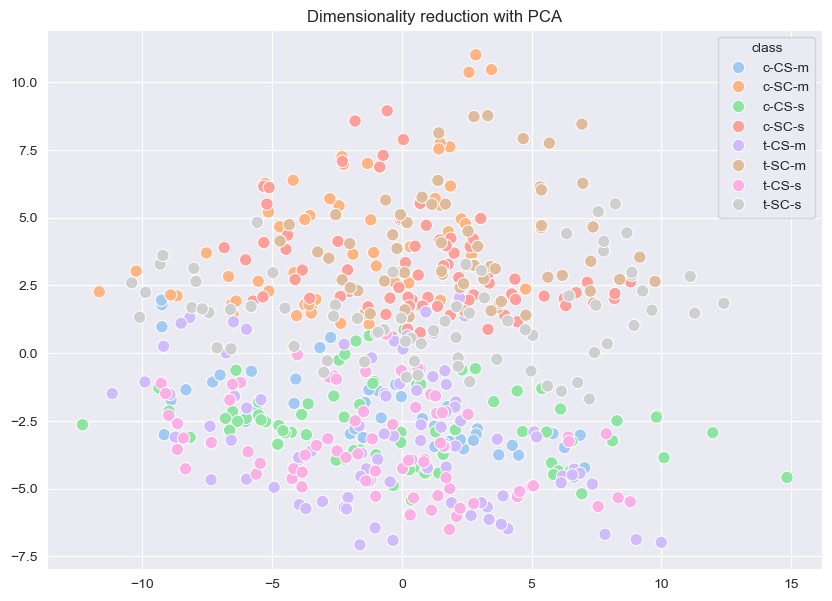

In [7]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=y, s=80, palette="pastel")
plt.title("Dimensionality reduction with PCA")
plt.grid(True)
plt.show()

## Gaussian Mixture

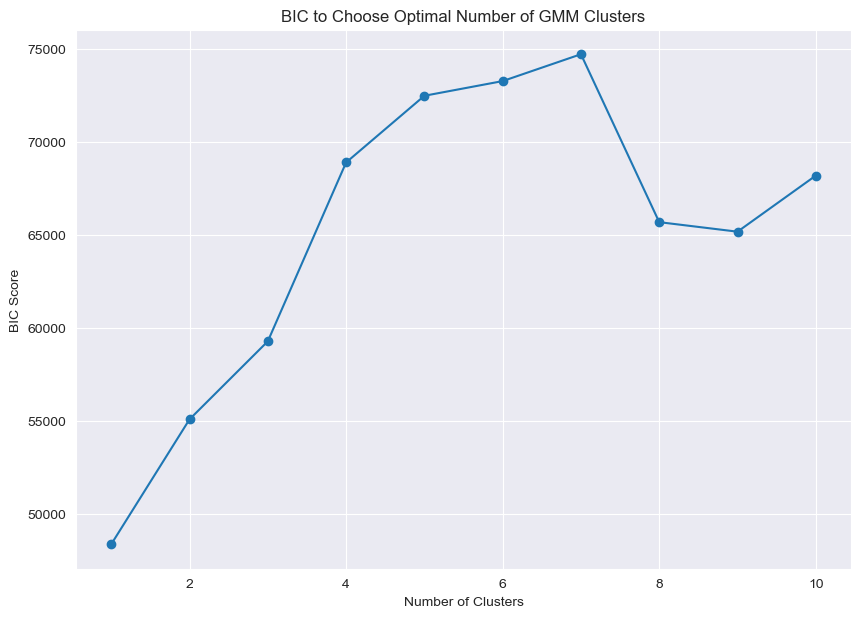

In [9]:
bic_scores = []
n_range = range(1, 11)

for n in n_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=0)
    gmm.fit(X)
    bic_scores.append(gmm.bic(X))

plt.figure(figsize=(10, 7))
plt.plot(n_range, bic_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('BIC Score')
plt.title('BIC to Choose Optimal Number of GMM Clusters')
plt.grid(True)
plt.show()

Because the highest BIC score is for 7+1 clusters, so 8 is the number of clusters we will use in GMM.

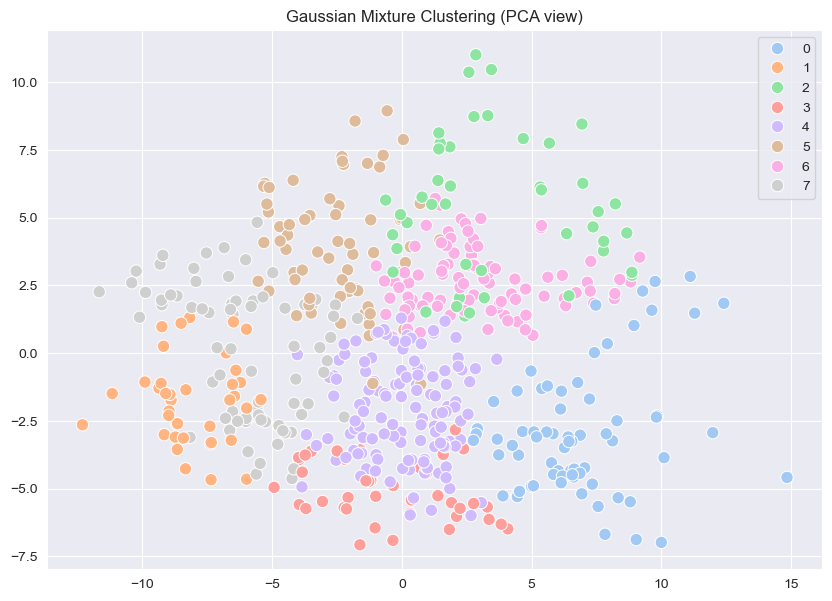

In [10]:
gmm = GaussianMixture(n_components=8, covariance_type='full', random_state=0)
gmm.fit(X)
y_pred_gmm = gmm.fit_predict(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=y_pred_gmm, palette="pastel", s=80)
plt.title("Gaussian Mixture Clustering (PCA view)")
plt.show()

# K-Means

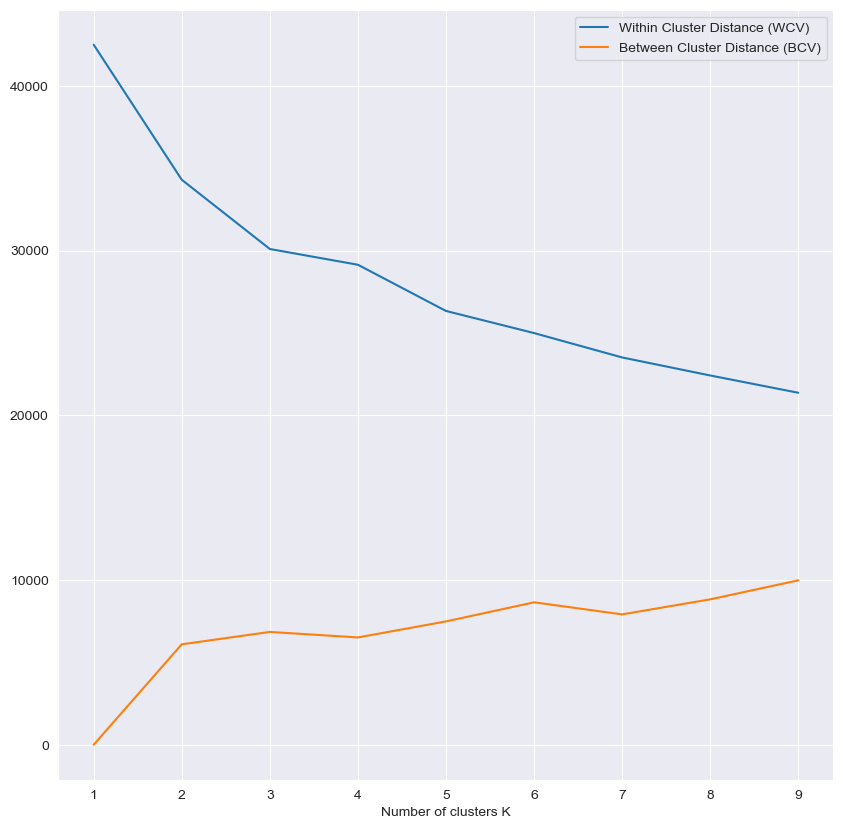

In [11]:
fig1 = plt.figure(figsize=(10, 10))
wcv = {}
bcv = {}

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k,max_iter=10000).fit(X)
    wcv[k] = kmeans.inertia_
    centers = kmeans.cluster_centers_
    BCV = 0
    for i in range(len(centers)):
        for j in range(len(centers)):
            BCV += distance.euclidean(centers[i], centers[j])**2
    if(k==1):
        bcv[1] = 0
    else:
        bcv[k] = BCV/(k*(k-1))*100
plt.plot(list(wcv.keys()), list(wcv.values()), label="Within Cluster Distance (WCV)")
plt.plot(list(bcv.keys()), list(bcv.values()), label="Between Cluster Distance (BCV)")
plt.xlabel("Number of clusters K")
plt.legend()
plt.show()


Based on the elbow method using WCV and BCV the number of clusters is 3 for KMeans

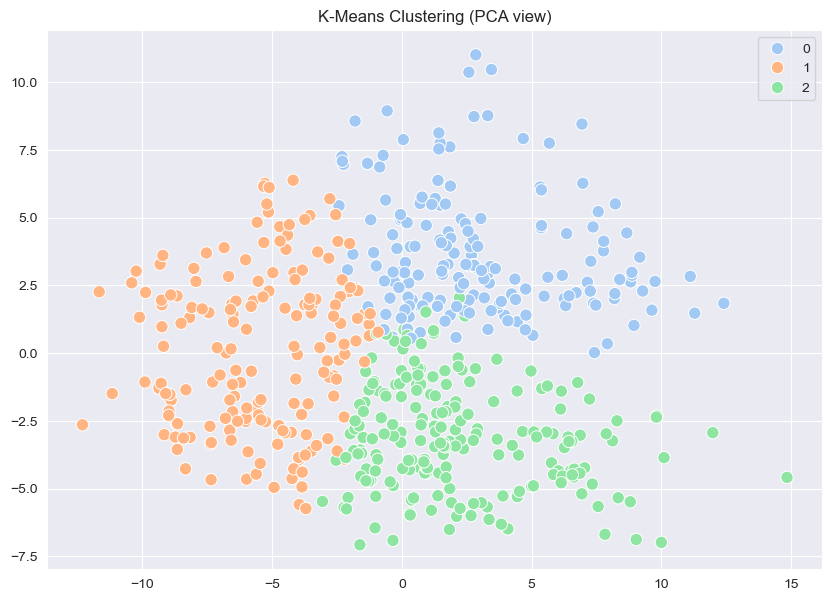

In [12]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10, init='k-means++', max_iter=10000)
y_pred_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=y_pred_kmeans, palette="pastel", s=80)
plt.title("K-Means Clustering (PCA view)")
plt.show()

# Hierarchical Clustering

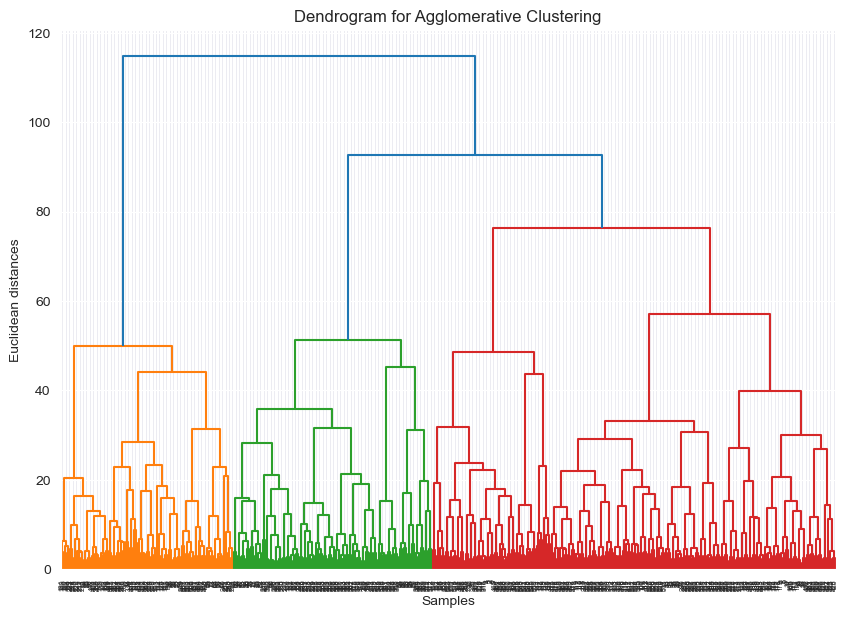

In [31]:
linked = linkage(X, method='ward')
plt.figure(figsize=(10, 7))
dendrogram(linked)
plt.title("Dendrogram for Agglomerative Clustering")
plt.xlabel("Samples")
plt.ylabel("Euclidean distances")
plt.show()

Based on the dendrogram, the number of clusters for Agglomerative Clustering is 3.

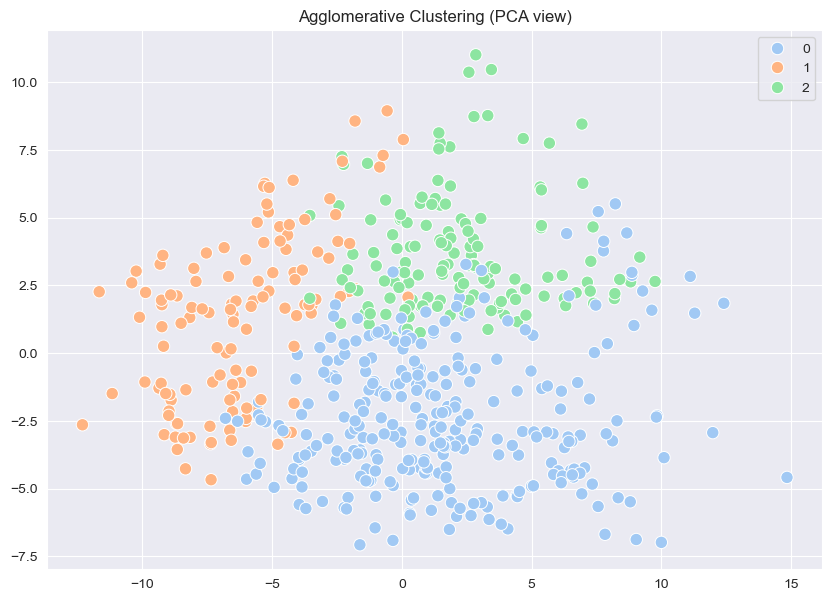

In [32]:
hierarchical = AgglomerativeClustering(n_clusters=3)
y_pred_hierarchical = hierarchical.fit_predict(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=y_pred_hierarchical, palette="pastel", s=80)
plt.title("Agglomerative Clustering (PCA view)")
plt.show()

# DBSCAN

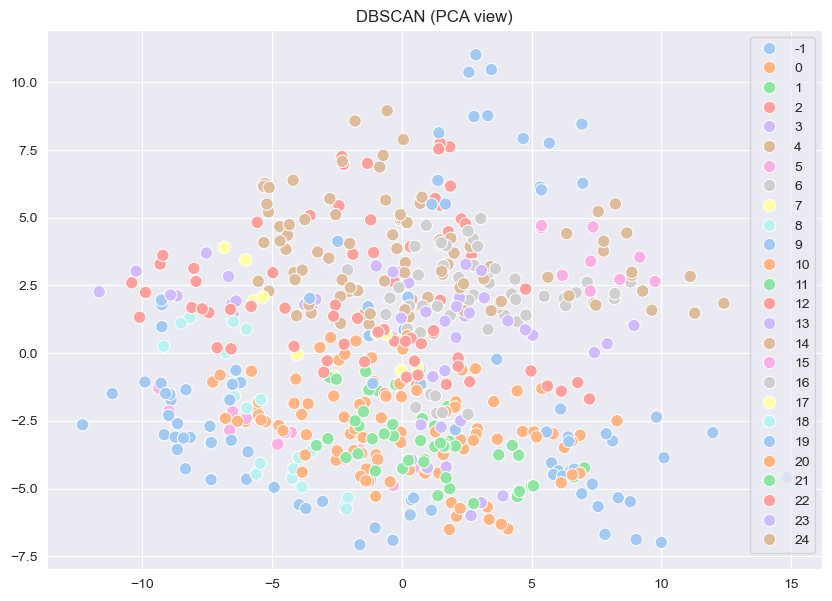

In [26]:
dbscan = DBSCAN(eps=5, min_samples=5)
y_pred_dbscan = dbscan.fit_predict(X)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=y_pred_dbscan, palette="pastel", s=80)
plt.title("DBSCAN (PCA view)")
plt.show()